<a id="perceptron"></a>
# The single perceptron

$$z = \sum_i w_i x_i + b \qquad y = \begin{cases} 1 & z > 0 \\ 0 & \text{otherwise}\end{cases}$$

A weighted sum, then a threshold. Nothing else.


In [ ]:
from viz import *


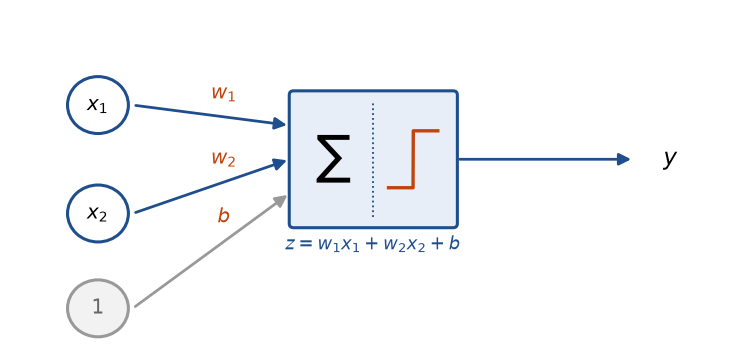

In [ ]:
diagram()


So let's see if we can use this perceptron to learn the **AND** function.

| $x_1$ | $x_2$ | $x_1 \wedge x_2$ |
|:-----:|:-----:|:----------------:|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | **1** |

Fire only when both inputs are on.


Start it off deliberately wrong. Then, for every corner it gets wrong, nudge
the weights in the direction that would have fixed it:

$$\text{error} = t - y \qquad w_i \mathrel{+}= \eta\,\text{error}\,x_i \qquad b \mathrel{+}= \eta\,\text{error}$$

Right answers change nothing. Only mistakes move the line.


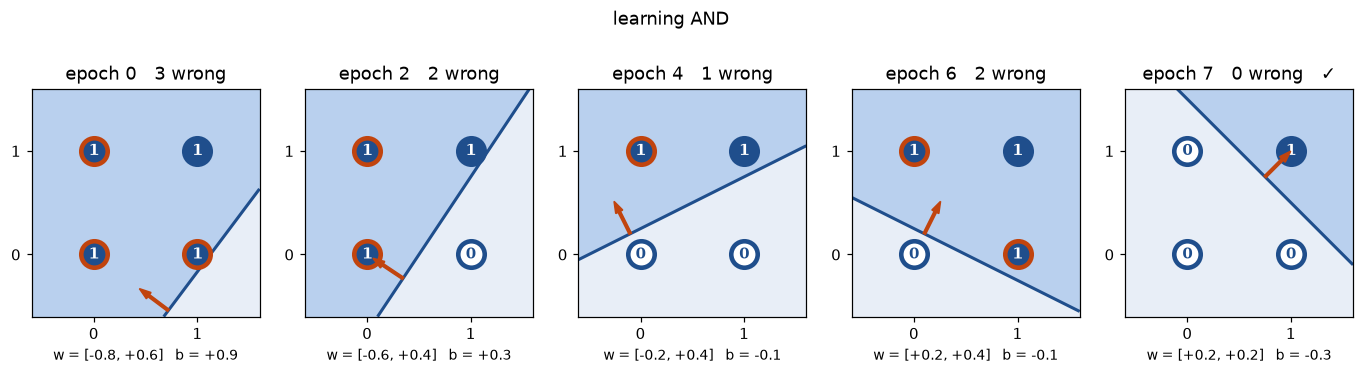

In [ ]:
learn()


## XOR

Now try **XOR** — fire when the inputs *disagree*.

| $x_1$ | $x_2$ | $x_1 \oplus x_2$ |
|:-----:|:-----:|:----------------:|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

The two corners that must fire sit on one diagonal; the two that must stay
quiet sit on the other. **No single perceptron can ever learn this.**

Not "we haven't found the weights yet" — there are none. The perceptron's
output is decided by which side of the line $z = 0$ a point falls on, so
whatever $w$ and $b$ you choose, the 1s must end up on one side and the 0s on
the other. Here they interleave, and one straight line cannot separate one
diagonal from the other.

The learning rule will keep pushing forever and never settle.


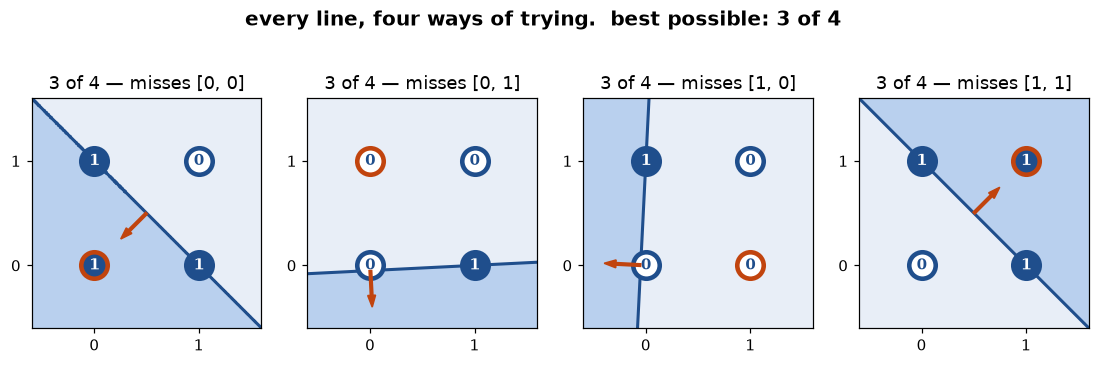

In [ ]:
no_line()


<a id="mlp"></a>
# The multiple layer perceptron


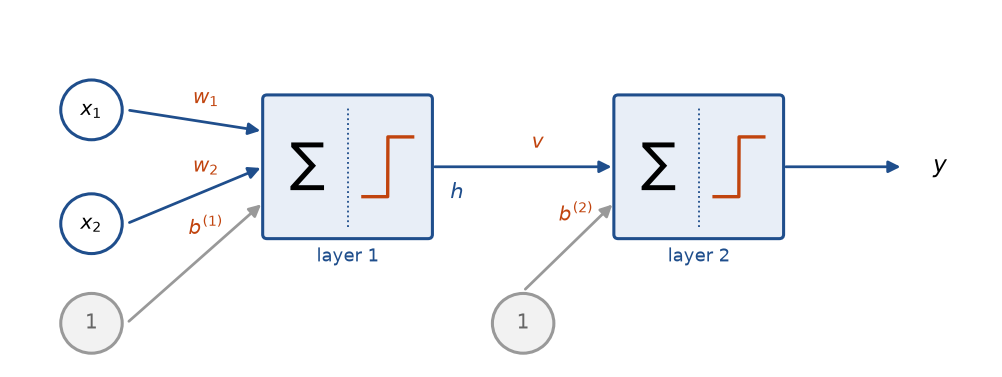

In [ ]:
mlp_diagram()


**This still can't do XOR.**

Layer 1 draws one line, and hands layer 2 a single bit $h$. Layer 2 sees nothing
but that bit, so all it can do is pass it on, invert it, or ignore it:

$$y = \text{step}(v\,h + b^{(2)}) \quad\Longrightarrow\quad y \in \{\,h,\ \text{not}\ h,\ 0,\ 1\,\}$$

The answer is still decided by which side of layer 1's single line you fell on.
Stacking bought nothing.

Depth is not the fix here — **width** is. Two neurons *side by side* in layer 1
draw two different lines, and layer 2 combines them. XOR is the strip between
them: above one line and below the other. That needs two lines, so it needs two
neurons in parallel.


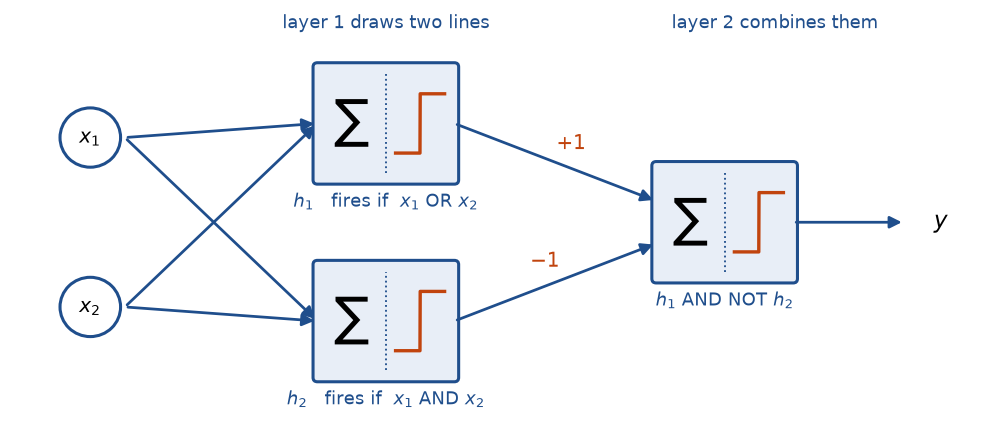

In [ ]:
xor_net_diagram()


**This one solves it.** Two neurons wide, then one to combine them:

$$h_1 = \text{step}(x_1 + x_2 - 0.5) \qquad h_2 = \text{step}(x_1 + x_2 - 1.5) \qquad y = \text{step}(h_1 - h_2 - 0.5)$$

$h_1$ is OR, $h_2$ is AND, and $y$ fires for *OR but not AND* — which is XOR.

| $x$ | $h_1$ | $h_2$ | $y$ |
|:--:|:--:|:--:|:--:|
| (0,0) | 0 | 0 | 0 |
| (0,1) | **1** | 0 | **1** |
| (1,0) | **1** | 0 | **1** |
| (1,1) | **1** | **1** | 0 |

Look at the middle two rows: the awkward diagonal corners now have **identical**
$(h_1, h_2)$. The hidden layer didn't draw a cleverer boundary — it moved the
points. In $(h_1, h_2)$ coordinates the two 1s have collapsed onto each other,
and a single line separates them from the rest. That line is layer 2.

Every neuron here is still a straight line. XOR is what you get by keeping one
and subtracting the other.

One catch: this network **exists**, but the learning rule from earlier cannot
find it. That rule only knows how to blame the neuron that produced the wrong
answer — it has nothing to say to a hidden neuron. Closing that gap is
backpropagation.


<a id="backprop"></a>
# Backpropagation


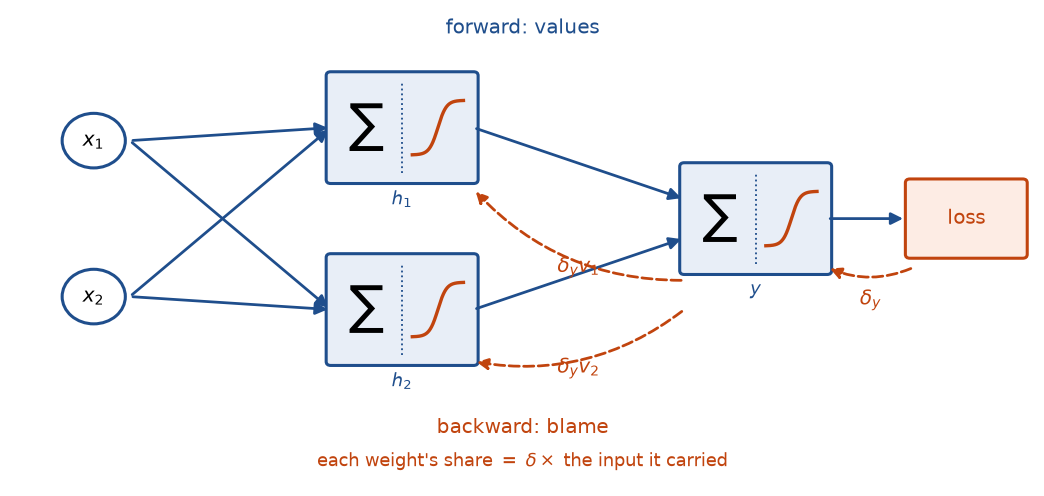

In [ ]:
backprop_diagram()


<a id="experiment-1"></a>
# Experiment #1


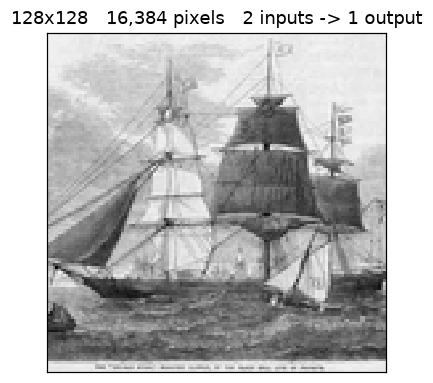

In [ ]:
target(128)


We are going to create a neural network that can predict this.

We will be taking $x, y$ values as input and outputting brightness.

$$(x,\ y) \;\longrightarrow\; \text{network} \;\longrightarrow\; \text{brightness}$$

Two numbers in, one number out. The network never sees the picture — only one
pixel's coordinates at a time, and how bright that pixel should be. If it can
learn that mapping, the image comes back.

Every pixel is one training example, so a $128 \times 128$ image gives
**16,384 examples**.


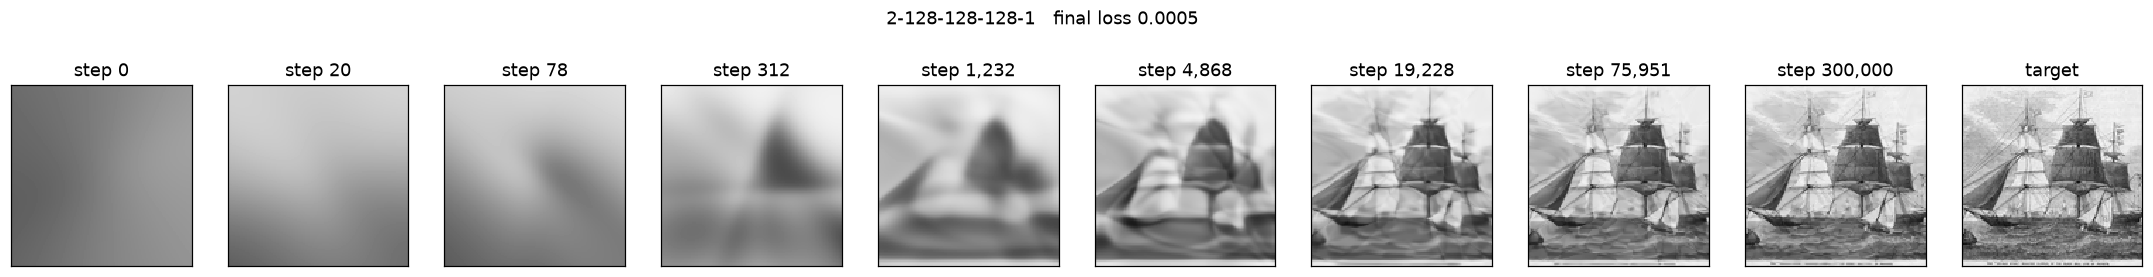

In [ ]:
learn_image(steps=300_000, frames=9)


The network starts as a flat grey field — a random function of two numbers, with
no idea a ship exists. Then, in order: **the horizon, the dark mass of the
mainsail, the hull, the individual sails, and finally the rigging.**

It learns the picture from low frequencies upward. Big smooth shapes are cheap;
fine detail is expensive and arrives last — but it does arrive.

There is no wall here, only a price. Getting from *recognisable ship* to *near
copy* cost 25× more steps than getting to recognisable in the first place.


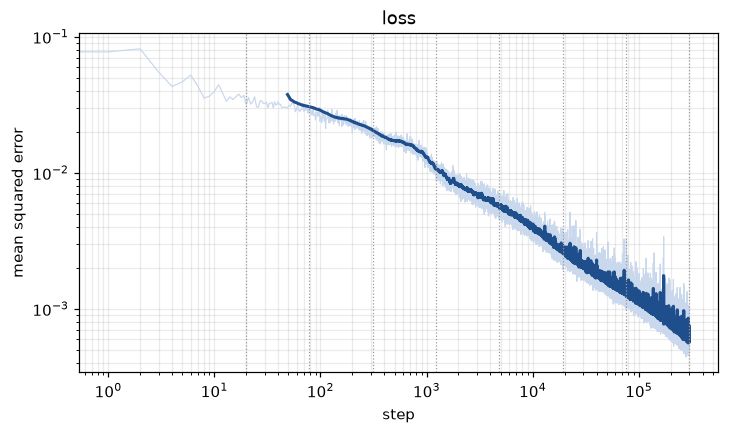

In [ ]:
loss_chart()


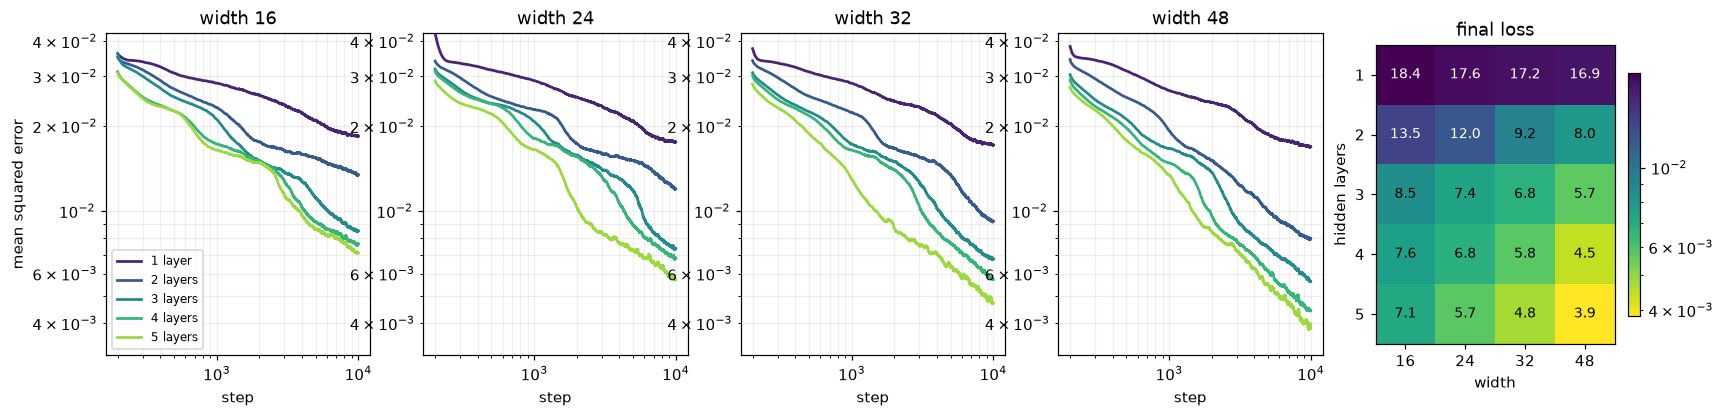

In [ ]:
runs = arch_sweep(steps=10_000)   # 20 shapes, none with more parameters than pixels
show_sweep(runs)


Now hold the budget **fixed** at 8,192 parameters — exactly half the pixel count,
so every network must compress 2:1 — and spend it differently. One hidden layer
gets 2,048 neurons; ten layers get 29 each.

The dashed line is a deliberate saboteur: same budget, but everything is forced
through three width-2 layers first.


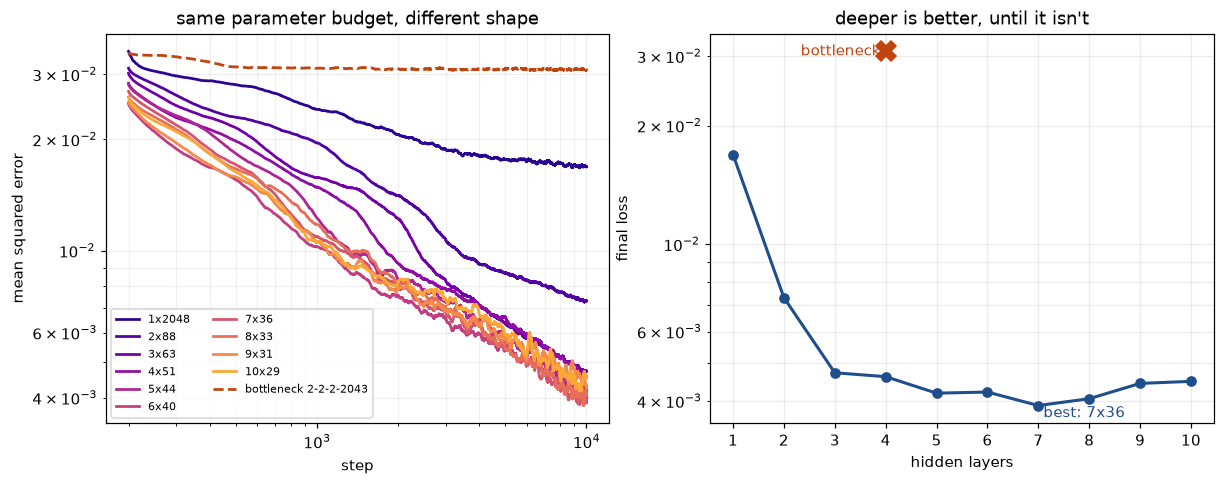

In [ ]:
show_budget(budget_sweep(steps=10_000))   # 8,192 params every time, shape varies


Same 8,192 numbers every time. The results span **8×**.

- **One wide layer is the worst honest shape** — 2,048 neurons, 4.3× worse than
  the best, and already stalling by 10,000 steps. A single layer can only add
  bumps together; it has no way to build on its own work.
- **Depth pays quickly, then stops.** Most of the gain is in the first three
  layers. From 3 to 8 everything sits within 20% of best, and past 8 it drifts
  back up. The optimum is a broad basin, not a knife edge.
- **The saboteur is the point.** Identical parameter count, 7.9× worse, and its
  curve is nearly flat — it stopped learning around step 200. Once the image has
  been squeezed into two numbers, nothing downstream can recover it.

So parameter count is not capacity. **The narrowest layer is the ceiling**, and
everything spent after it is spent on what survived.
